In [26]:
import pandas as pd 
import numpy as np
import seaborn as sns
import tensorflow as tf 
from tensorflow.keras.layers import Dense , Dropout ,Conv2D , MaxPooling2D , Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report , confusion_matrix
import matplotlib.pyplot as plt

In [2]:
train_df = pd.read_csv("fashion-mnist_train.csv")
test_df = pd.read_csv("fashion-mnist_test.csv")

In [15]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]    

In [5]:
X_train = train_df.drop("label", axis=1).values
y_train = train_df["label"].values

X_test = test_df.drop("label", axis=1).values
y_test = test_df["label"].values

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

# One-hot encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)



In [6]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10,activation='softmax'))

C:\Users\admin\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history=model.fit(
    X_train,y_train_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.7660 - loss: 0.6418 - val_accuracy: 0.8550 - val_loss: 0.4139
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.8452 - loss: 0.4316 - val_accuracy: 0.8770 - val_loss: 0.3397
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.8634 - loss: 0.3761 - val_accuracy: 0.8803 - val_loss: 0.3214
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.8757 - loss: 0.3415 - val_accuracy: 0.8932 - val_loss: 0.2945
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.8873 - loss: 0.3144 - val_accuracy: 0.8982 - val_loss: 0.2799
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.8935 - loss: 0.2939 - val_accuracy: 0.9072 - val_loss: 0.2636
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.8997 - loss: 0.2734 - val_accuracy: 0.9091 - val_loss: 0.2542
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.9035 - loss: 0.2574 - 

In [11]:
loss,accuracy=model.evaluate(X_test,y_test_cat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9192 - loss: 0.2263


In [21]:
print("\nTest Accuracy:", accuracy)


Test Accuracy: 0.8787999749183655


In [18]:
y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)
y_true = y_test

print("Classification Report",classification_report(y_test,y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Classification Report               precision    recall  f1-score   support

           0       0.88      0.85      0.87      1000
           1       0.99      0.98      0.99      1000
           2       0.89      0.85      0.87      1000
           3       0.91      0.94      0.93      1000
           4       0.87      0.89      0.88      1000
           5       0.98      0.98      0.98      1000
           6       0.75      0.78      0.77      1000
           7       0.96      0.96      0.96      1000
           8       0.99      0.99      0.99      1000
           9       0.97      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



In [19]:
print("\nSample Predictions:")
for i in range(20):
    print("Actual:", class_names[y_true[i]],
          "| Predicted:", class_names[y_pred_classes[i]])


Sample Predictions:
Actual: T-shirt/top | Predicted: T-shirt/top
Actual: Trouser | Predicted: Trouser
Actual: Pullover | Predicted: Pullover
Actual: Pullover | Predicted: Shirt
Actual: Dress | Predicted: Dress
Actual: Pullover | Predicted: Shirt
Actual: Bag | Predicted: Bag
Actual: Shirt | Predicted: Shirt
Actual: Sandal | Predicted: Sandal
Actual: T-shirt/top | Predicted: T-shirt/top
Actual: Dress | Predicted: Dress
Actual: Coat | Predicted: Pullover
Actual: Coat | Predicted: Coat
Actual: Shirt | Predicted: Shirt
Actual: Bag | Predicted: Bag
Actual: Sandal | Predicted: Sandal
Actual: Shirt | Predicted: Shirt
Actual: Dress | Predicted: Dress
Actual: Shirt | Predicted: Shirt
Actual: Coat | Predicted: Coat


<function matplotlib.pyplot.show(close=None, block=None)>

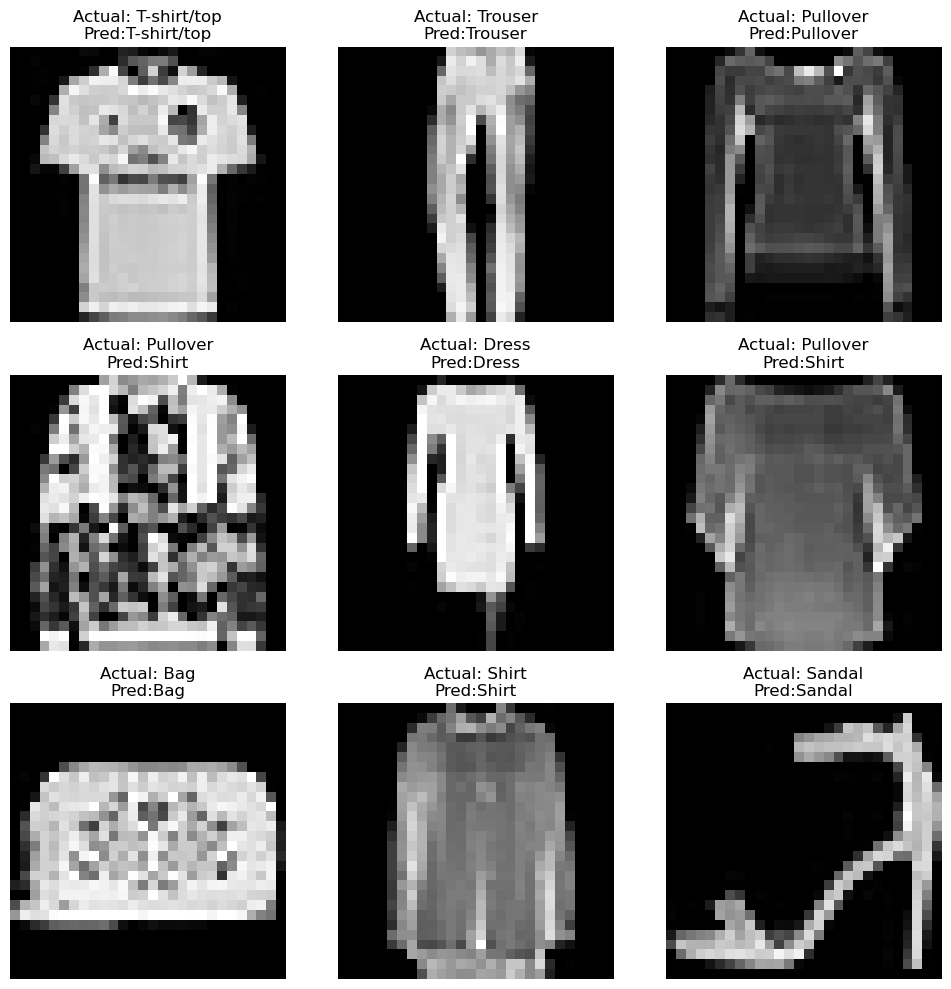

In [20]:
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i].reshape(28,28),cmap='gray')
    plt.title(f"Actual: {class_names[y_test[i]]}\nPred:{class_names[y_pred_classes[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show

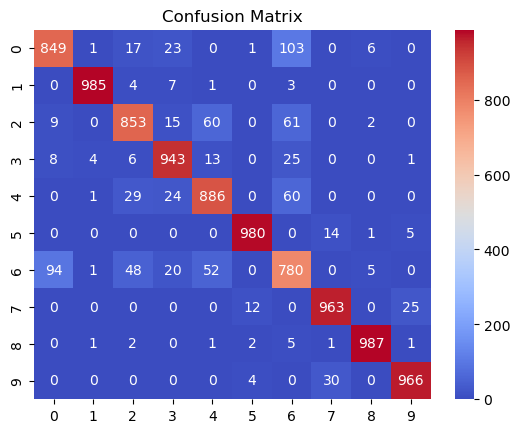

In [27]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap="coolwarm")
plt.title("Confusion Matrix")
plt.show()